In [53]:
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import pandas as pd

PKLs = []
PKL_titles = []
DIR = "./"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

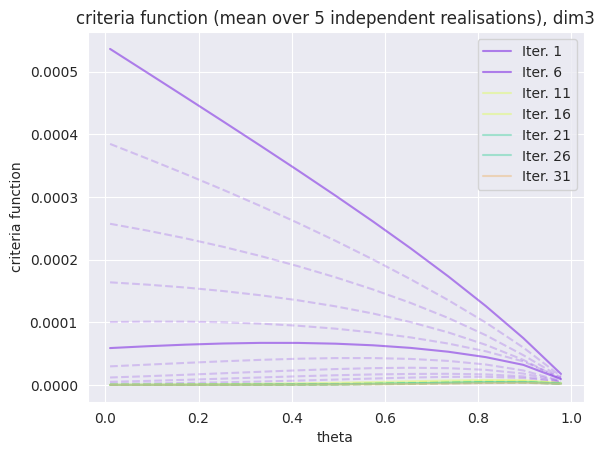

In [56]:
GRID_ESJD = jnp.linspace(0.01, 8, 100)

NUM_COLORS = 30
color_set = set()
while len(color_set)<NUM_COLORS:
    random_integers = [np.random.randint(0, 255)/255 for _ in range(3)]
    color_set.add(tuple(random_integers))


color_set = list(color_set)
color_set = [tuple(n) for n in color_set]
idx = 0
mpm1 = PKLs[idx]['res'][0].shape[2]*(PKLs[idx]['res'][0].shape[3]-1)
for j in range(PKLs[idx]['res'][5].shape[1]):
    criteria_function = PKLs[idx]['res'][5].mean(axis=0) / mpm1
    plt.plot(GRID_ESJD, criteria_function[j], label=f"Iter. {str(j+1)}" if j%5==0 else None, alpha=0.5 if j%5==0 else 0.2, color=color_set[j//10], linestyle="solid" if j%5==0 else "--")
plt.legend()
plt.title(f"criteria function (mean over {PKLs[idx]['res'][5].shape[0]} independent realisations), dim{PKLs[idx]['res'][0].shape[-1]}")
plt.ylabel("criteria function")
plt.xlabel("theta")
plt.savefig(f"{PKL_titles[idx]}criteria_function.png")


In [52]:
criteria_function[32]

Array([0.0000000e+00, 2.6905840e-09, 1.0949839e-07, 2.9778167e-07,
       5.3636745e-07, 8.3352916e-07, 1.1739429e-06, 1.5355718e-06,
       1.9091285e-06, 2.2912852e-06, 2.6788589e-06, 3.0675396e-06,
       3.4523141e-06, 3.8282301e-06, 4.1908888e-06, 4.5366228e-06,
       4.8624925e-06, 5.1662096e-06, 5.4460638e-06, 5.7008365e-06,
       5.9297590e-06, 6.1324426e-06, 6.3088310e-06, 6.4591527e-06,
       6.5838954e-06, 6.6837692e-06, 6.7596957e-06, 6.8127820e-06,
       6.8443092e-06, 6.8557147e-06, 6.8485574e-06, 6.8244908e-06,
       6.7852202e-06, 6.7324613e-06, 6.6678981e-06, 6.5931454e-06,
       6.5097211e-06, 6.4190194e-06, 6.3222978e-06, 6.2206718e-06,
       6.1151163e-06, 6.0064735e-06, 5.8954570e-06, 5.7826737e-06,
       5.6686299e-06, 5.5537521e-06, 5.4383968e-06, 5.3228609e-06,
       5.2073974e-06, 5.0922245e-06, 4.9775272e-06, 4.8634693e-06,
       4.7501971e-06, 4.6378427e-06, 4.5265219e-06, 4.4163498e-06,
       4.3074238e-06, 4.1998383e-06, 4.0936811e-06, 3.9890310e

In [25]:
PKLs[0]['res'][0].shape[1]

35